# NHS Resolution Claim Classification Pipeline  
### Severity + Harm Theme + Multi‑Task + SHAP + Early Stopping

This notebook trains:

- **Single‑task severity classifier** (BERT + Longformer)  
- **Single‑task harm‑theme classifier** (BERT + Longformer)  
- **Multi‑task Longformer** (severity + theme jointly)  
- **SHAP explainability** for both heads  
- **Confusion matrices**  
- **Early stopping** to prevent overfitting  

Longformer is used for long clinical narratives (up to 2048 tokens).

#### with early stopping after 1 epochs where validation loss goes up, low learning rate, warm up, bottom 6 layers frozen (stability and efficiency with a hundred example)

## 00 - notebook setup

In [35]:
# windows or wsl
import platform
print(platform.system())
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

Windows
2.5.1+cu121
12.1
True
NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

import shap
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

IPython could not be loaded!


'cuda'

## 01 - Load dataset

In [3]:
df = pd.read_json("synthetic_claims.json")
df.head()

,id,severity,theme,department,claim_text
0,1,high,diagnostic_error,ED/Cardiology,"The patient, a 68-year-old male with hypertens..."
1,2,high,failure_to_escalate,Surgery/ICU,A 54-year-old female underwent elective laparo...
2,3,low,diagnostic_error,ED/Fracture Clinic,A 32-year-old male attended A&E after falling ...
3,4,high,delay_in_treatment,ED/Respiratory,A 76-year-old patient with COPD presented with...
4,5,high,fetal_monitoring_failure,Maternity,A 29-year-old primigravida presented in labour...


## 02 - Label engineering

In [4]:
severity_map = {"low": 0, "moderate": 1, "high": 2}

theme_map = {
    "diagnostic_error": 0,
    "delay_in_treatment": 1,
    "failure_to_escalate": 2,
    "post_op_complication": 3,
    "medication_error": 4,
    "communication_failure": 5,
    "surgical_error": 6,
    "administrative_delay": 7,
    "risk_assessment_failure": 8,
    "delivery_complication": 9,
    "fetal_monitoring_failure": 10,
    "diagnostic_delay": 11
}

df["severity_label"] = df["severity"].map(severity_map)
df["theme_label"] = df["theme"].map(theme_map)
# ensure theme labels are integers (prevents BCEWithLogitsLoss)
df["theme_label"] = df["theme_label"].astype(int)

df[["severity_label", "theme_label"]].value_counts()

severity_label  theme_label
2               0              12
                1              12
                2              10
1               3              10
                4               9
0               7               9
1               5               9
2               11              8
1               0               8
2               6               7
0               0               1
2               10              1
1               11              1
2               8               1
                9               1
1               1               1
Name: count, dtype: int64

In [5]:
df["theme"].unique()

<ArrowStringArray>
[        'diagnostic_error',      'failure_to_escalate',
       'delay_in_treatment', 'fetal_monitoring_failure',
         'diagnostic_delay',  'risk_assessment_failure',
     'post_op_complication',    'delivery_complication',
           'surgical_error',         'medication_error',
     'administrative_delay',    'communication_failure']
Length: 12, dtype: str

## 03 - Train/Validation Split

In [6]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)

## 04 - Tokenisers & Models

In [7]:
BERT_NAME = "emilyalsentzer/Bio_ClinicalBERT"
LONGFORMER_NAME = "yikuan8/Clinical-Longformer"

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
long_tokenizer = AutoTokenizer.from_pretrained(LONGFORMER_NAME)

bert_sev_model = AutoModelForSequenceClassification.from_pretrained(BERT_NAME, num_labels=3).to(DEVICE)
long_sev_model = AutoModelForSequenceClassification.from_pretrained(LONGFORMER_NAME, num_labels=3).to(DEVICE)

bert_theme_model = AutoModelForSequenceClassification.from_pretrained(BERT_NAME, num_labels=len(theme_map)).to(DEVICE)
long_theme_model = AutoModelForSequenceClassification.from_pretrained(LONGFORMER_NAME, num_labels=len(theme_map)).to(DEVICE)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of LongformerForSequenceClassification were not initialized from the model checkpoint at yikuan8/Clinical-Longformer and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some we

## 05 - Build Single‑Task Datasets (Severity + Theme)

#### Tokenisation functions

In [8]:
def tokenize_bert(batch):
    return bert_tokenizer(batch["claim_text"], padding="max_length", truncation=True, max_length=256)

def tokenize_longformer(batch):
    return long_tokenizer(batch["claim_text"], padding="max_length", truncation=True, max_length=1024) # was 2048

#### Apply tokenisation

In [9]:
sev_train_bert = train_ds.map(tokenize_bert, batched=True)
sev_val_bert = val_ds.map(tokenize_bert, batched=True)

sev_train_long = train_ds.map(tokenize_longformer, batched=True)
sev_val_long = val_ds.map(tokenize_longformer, batched=True)

theme_train_bert = train_ds.map(tokenize_bert, batched=True)
theme_val_bert = val_ds.map(tokenize_bert, batched=True)

theme_train_long = train_ds.map(tokenize_longformer, batched=True)
theme_val_long = val_ds.map(tokenize_longformer, batched=True)

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

#### Rename labels

In [10]:
sev_train_bert = sev_train_bert.rename_column("severity_label", "labels")
sev_val_bert = sev_val_bert.rename_column("severity_label", "labels")

sev_train_long = sev_train_long.rename_column("severity_label", "labels")
sev_val_long = sev_val_long.rename_column("severity_label", "labels")

theme_train_bert = theme_train_bert.rename_column("theme_label", "labels")
theme_val_bert = theme_val_bert.rename_column("theme_label", "labels")

theme_train_long = theme_train_long.rename_column("theme_label", "labels")
theme_val_long = theme_val_long.rename_column("theme_label", "labels")

#### Remove unused columns

In [11]:
cols = ["id", "severity", "theme", "department", "claim_text"]

sev_train_bert = sev_train_bert.remove_columns(cols)
sev_val_bert = sev_val_bert.remove_columns(cols)

sev_train_long = sev_train_long.remove_columns(cols)
sev_val_long = sev_val_long.remove_columns(cols)

theme_train_bert = theme_train_bert.remove_columns(cols)
theme_val_bert = theme_val_bert.remove_columns(cols)

theme_train_long = theme_train_long.remove_columns(cols)
theme_val_long = theme_val_long.remove_columns(cols)

#### set format

In [12]:
for ds in [sev_train_bert, sev_val_bert, sev_train_long, sev_val_long,
           theme_train_bert, theme_val_bert, theme_train_long, theme_val_long]:
    ds.set_format("torch")

## 06 - Train single task model

#### metrics

In [13]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

#### load models

In [14]:
bert_sev_model = AutoModelForSequenceClassification.from_pretrained(BERT_NAME, num_labels=3).to(DEVICE)
long_sev_model = AutoModelForSequenceClassification.from_pretrained(LONGFORMER_NAME, num_labels=3).to(DEVICE)
long_sev_model.gradient_checkpointing_enable()

bert_theme_model = AutoModelForSequenceClassification.from_pretrained(BERT_NAME, num_labels=len(theme_map)).to(DEVICE)
# force single‑label classification (prevents BCEWithLogitsLoss)
bert_theme_model.config.problem_type = "single_label_classification"
long_theme_model = AutoModelForSequenceClassification.from_pretrained(LONGFORMER_NAME, num_labels=len(theme_map)).to(DEVICE)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of LongformerForSequenceClassification were not initialized from the model checkpoint at yikuan8/Clinical-Longformer and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some we

#### training arguments

In [15]:
bert_args = TrainingArguments(
    output_dir="./bert",
    num_train_epochs=20,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-5,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    warmup_steps=200,        # ← UPDATED (was 50)
    max_grad_norm=1.0,
    fp16=True               # ← NEW (mixed precision for speed)
)

long_args = TrainingArguments(
    output_dir="./longformer",
    num_train_epochs=20,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=2e-5,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",          # ← FIXED
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    warmup_steps=50,
    max_grad_norm=1.0
)

In [16]:
# work on an old GPU
long_args = TrainingArguments(
    output_dir="./longformer",
    num_train_epochs=20,
    per_device_train_batch_size=1,     # ← FIXED
    per_device_eval_batch_size=1,      # ← FIXED
    learning_rate=2e-5,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    warmup_steps=200,                   # more warm up steps
    max_grad_norm=1.0,
    gradient_checkpointing=True,        # ← HUGE FIX
    fp16=True                         # floating point precision
)

#### trainers - with early stopping (just 1 epoch because smaller learning steps, not 2)

In [17]:
bert_sev_trainer = Trainer(
    model=bert_sev_model,
    args=bert_args,
    train_dataset=sev_train_bert,
    eval_dataset=sev_val_bert,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

In [18]:
long_sev_trainer = Trainer(
    model=long_sev_model,
    args=long_args,
    train_dataset=sev_train_long,
    eval_dataset=sev_val_long,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

In [19]:
bert_theme_trainer = Trainer(
    model=bert_theme_model,
    args=bert_args,
    train_dataset=theme_train_bert,
    eval_dataset=theme_val_bert,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

In [20]:
long_theme_trainer = Trainer(
    model=long_theme_model,
    args=long_args,
    train_dataset=theme_train_long,
    eval_dataset=theme_val_long,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

#### train

In [21]:
bert_sev_trainer.train()
long_sev_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.041700,0.946118,0.600000,0.359307
2,0.991600,0.863989,0.550000,0.296552
3,0.869100,0.759790,0.900000,0.613757
4,0.761400,0.645886,0.900000,0.613757
5,0.607400,0.520715,0.950000,0.964519
6,0.453500,0.416272,0.950000,0.964519
7,0.253100,0.300908,0.900000,0.929630
8,0.122300,0.297355,0.900000,0.929630
9,0.049100,0.268347,0.950000,0.964519
10,0.017100,0.331625,0.950000,0.964519


Initializing global attention on CLS token...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.054200,0.720239,0.850000,0.577540
2,0.742200,0.382879,0.950000,0.964519
3,0.413500,0.367482,0.950000,0.964519
4,0.241800,0.401505,0.950000,0.964519


TrainOutput(global_step=320, training_loss=0.6129109382629394, metrics={'train_runtime': 1515.1621, 'train_samples_per_second': 1.056, 'train_steps_per_second': 1.056, 'total_flos': 210194027642880.0, 'train_loss': 0.6129109382629394, 'epoch': 4.0})

In [22]:
bert_theme_trainer.train()
long_theme_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.525300,2.586816,0.000000,0.000000
2,2.398300,2.437793,0.050000,0.013333
3,2.324600,2.356592,0.450000,0.169753
4,2.244700,2.277978,0.500000,0.195419
5,2.100200,2.157666,0.500000,0.335948
6,1.944100,2.023486,0.550000,0.414462
7,1.688100,1.734522,0.600000,0.477381
8,1.433200,1.543262,0.650000,0.542857
9,1.100500,1.251965,0.850000,0.626667
10,0.827000,1.064343,0.850000,0.660000


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.453000,2.254395,0.400000,0.065844
2,1.998900,1.587744,0.750000,0.500784
3,1.141100,0.839996,0.900000,0.694118
4,0.443200,0.590929,0.900000,0.694118
5,0.189600,0.665224,0.850000,0.677778


TrainOutput(global_step=400, training_loss=1.2451629257202148, metrics={'train_runtime': 1641.0753, 'train_samples_per_second': 0.975, 'train_steps_per_second': 0.975, 'total_flos': 262759543603200.0, 'train_loss': 1.2451629257202148, 'epoch': 5.0})

## 07 - Single task comparison

In [23]:
bert_sev_metrics = bert_sev_trainer.evaluate()
long_sev_metrics = long_sev_trainer.evaluate()

bert_theme_metrics = bert_theme_trainer.evaluate()
long_theme_metrics = long_theme_trainer.evaluate()

pd.DataFrame({
    "Model": ["BERT", "Longformer"],
    "Severity Accuracy": [bert_sev_metrics["eval_accuracy"], long_sev_metrics["eval_accuracy"]],
    "Severity F1": [bert_sev_metrics["eval_f1_macro"], long_sev_metrics["eval_f1_macro"]],
    "Theme Accuracy": [bert_theme_metrics["eval_accuracy"], long_theme_metrics["eval_accuracy"]],
    "Theme F1": [bert_theme_metrics["eval_f1_macro"], long_theme_metrics["eval_f1_macro"]],
})

,Model,Severity Accuracy,Severity F1,Theme Accuracy,Theme F1
0,BERT,0.95,0.964519,0.85,0.660000
1,Longformer,0.95,0.964519,0.90,0.694118


## 08 - Multi-task comparison

#### multi-task dataset

In [24]:
# --- Multi-task dataset ---
def tokenize_multitask(batch):
    return long_tokenizer(
        batch["claim_text"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

mt_train = train_ds.map(tokenize_multitask, batched=True)
mt_val = val_ds.map(tokenize_multitask, batched=True)

# Rename labels to match model forward() arguments
mt_train = mt_train.rename_column("severity_label", "labels_severity")
mt_train = mt_train.rename_column("theme_label", "labels_theme")

mt_val = mt_val.rename_column("severity_label", "labels_severity")
mt_val = mt_val.rename_column("theme_label", "labels_theme")

# Remove unused columns
cols = ["id", "severity", "theme", "department", "claim_text"]
mt_train = mt_train.remove_columns(cols)
mt_val = mt_val.remove_columns(cols)

mt_train.set_format("torch")
mt_val.set_format("torch")


Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

#### model

In [25]:
# --- Multi-task model ---
class MultiTaskLongformer(nn.Module):
    def __init__(self, model_name, num_severity=3, num_theme=12):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.encoder.gradient_checkpointing_enable()

        hidden = self.encoder.config.hidden_size
        self.sev_head = nn.Linear(hidden, num_severity)
        self.theme_head = nn.Linear(hidden, num_theme)
        self.loss_fn = nn.CrossEntropyLoss()

        # freeze lower layers
        for name, param in self.encoder.named_parameters():
            if any(f"layer.{i}" in name for i in range(7)):
                param.requires_grad = False

    def forward(self, input_ids, attention_mask, labels_severity=None, labels_theme=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0]

        sev_logits = self.sev_head(pooled)
        theme_logits = self.theme_head(pooled)

        loss = None
        if labels_severity is not None:
            loss = (
                self.loss_fn(sev_logits, labels_severity) +
                self.loss_fn(theme_logits, labels_theme)
            )

        return {"loss": loss, "severity_logits": sev_logits, "theme_logits": theme_logits}

#### Multi-task trainer with early stopping

In [26]:
# create model
multi_model = MultiTaskLongformer(LONGFORMER_NAME).to(DEVICE)

Some weights of LongformerModel were not initialized from the model checkpoint at yikuan8/Clinical-Longformer and are newly initialized: ['longformer.pooler.dense.bias', 'longformer.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
# --- Multi-task training args ---
mt_args = TrainingArguments(
    output_dir="./multitask",
    num_train_epochs=20,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    learning_rate=2e-5,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    warmup_steps=200,
    max_grad_norm=1.0,
    fp16=True
)

# --- Multi-task trainer ---
mt_trainer = Trainer(
    model=multi_model,
    args=mt_args,
    train_dataset=mt_train,
    eval_dataset=mt_val,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

In [28]:
# --- Train multi-task model ---
mt_trainer.train()

Epoch,Training Loss,Validation Loss
1,3.478600,3.374292
2,3.258500,2.863257
3,2.574800,2.162057
4,1.648200,1.572812
5,1.017200,1.179518
6,0.710600,1.016387
7,0.509600,0.942634
8,0.355000,1.024442


TrainOutput(global_step=640, training_loss=1.6940663576126098, metrics={'train_runtime': 2347.0867, 'train_samples_per_second': 0.682, 'train_steps_per_second': 0.682, 'total_flos': 0.0, 'train_loss': 1.6940663576126098, 'epoch': 8.0})

## 09 - Multi‑Task SHAP Explainability

#### prediction functions

def mt_pred_sev(texts):
    inputs = long_tokenizer(texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = multi_model(**inputs)
    return torch.softmax(out["severity_logits"], dim=-1).cpu().numpy()

def mt_pred_theme(texts):
    inputs = long_tokenizer(texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = multi_model(**inputs)
    return torch.softmax(out["theme_logits"], dim=-1).cpu().numpy()

#### SHAP explainers

# --- SHAP without Text masker (stable on NumPy >= 1.24) ---

def shap_predict_sev(token_ids):
    # token_ids is a list of tokenized inputs
    inputs = {
        "input_ids": torch.tensor(token_ids).to(DEVICE),
        "attention_mask": torch.tensor([[1]*len(token_ids[0])]).to(DEVICE)
    }
    with torch.no_grad():
        out = multi_model(**inputs)
    return torch.softmax(out["severity_logits"], dim=-1).cpu().numpy()

def shap_predict_theme(token_ids):
    inputs = {
        "input_ids": torch.tensor(token_ids).to(DEVICE),
        "attention_mask": torch.tensor([[1]*len(token_ids[0])]).to(DEVICE)
    }
    with torch.no_grad():
        out = multi_model(**inputs)
    return torch.softmax(out["theme_logits"], dim=-1).cpu().numpy()

# Tokenize the claim manually
claim = df["claim_text"].iloc[0]
tok = long_tokenizer(claim, padding="max_length", truncation=True, max_length=512)

token_ids = [tok["input_ids"]]

# Build SHAP explainers (no Text masker)
sev_explainer = shap.Explainer(shap_predict_sev, token_ids)
theme_explainer = shap.Explainer(shap_predict_theme, token_ids)

# Compute SHAP values
sev_shap = sev_explainer(token_ids, max_evals=200)
theme_shap = theme_explainer(token_ids, max_evals=200)

# Visualise
shap.plots.text(sev_shap[0])
shap.plots.text(theme_shap[0])



#### combined SHAP plot

tokens = long_tokenizer.tokenize(claim)
sev_vals = sev_shap[0].values[:len(tokens)]
theme_vals = theme_shap[0].values[:len(tokens)]

plt.figure(figsize=(14,5))
plt.plot(sev_vals, label="Severity SHAP", color="red")
plt.plot(theme_vals, label="Theme SHAP", color="blue")
plt.legend()
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.title("Combined SHAP — Severity vs Theme")
plt.show()

## 10 - Multi‑Task Confusion Matrices

In [29]:
# --- Multi-task prediction helpers ---
def predict_severity(text):
    tok = long_tokenizer(text, padding="max_length", truncation=True, max_length=512, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = multi_model(**tok)
    return int(torch.softmax(out["severity_logits"], dim=-1).argmax())

def predict_theme(text):
    tok = long_tokenizer(text, padding="max_length", truncation=True, max_length=512, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = multi_model(**tok)
    return int(torch.softmax(out["theme_logits"], dim=-1).argmax())


In [30]:
sev_preds = [predict_severity(t) for t in val_df["claim_text"]]
theme_preds = [predict_theme(t) for t in val_df["claim_text"]]


#### Severity CM

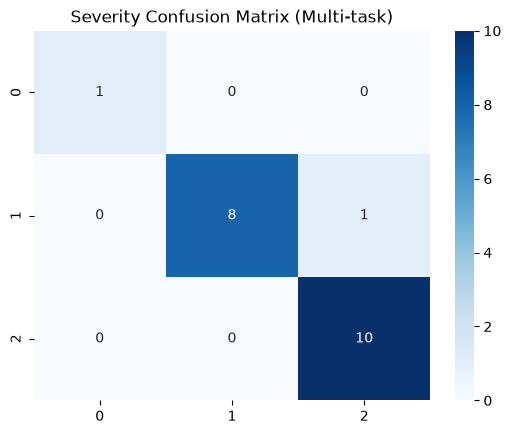

In [31]:
# --- Severity confusion matrix ---
sev_preds = [predict_severity(t) for t in val_df["claim_text"]]
sev_true = val_df["severity_label"].tolist()

cm_sev = confusion_matrix(sev_true, sev_preds)
sns.heatmap(cm_sev, annot=True, cmap="Blues", fmt="d")
plt.title("Severity Confusion Matrix (Multi-task)")
plt.show()

#### Theme CM

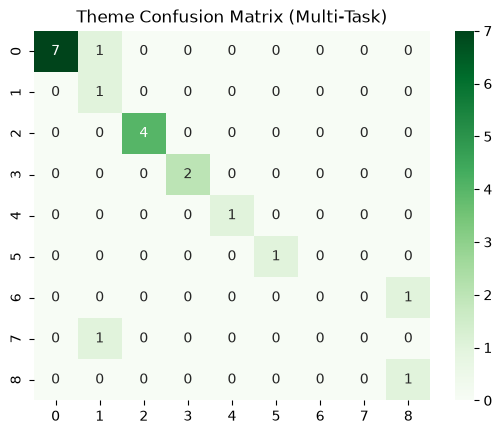

In [32]:
theme_preds = [predict_theme(t) for t in val_df["claim_text"]]
theme_true = val_df["theme_label"].tolist()

cm_theme = confusion_matrix(theme_true, theme_preds)

sns.heatmap(cm_theme, annot=True, cmap="Greens", fmt="d")
plt.title("Theme Confusion Matrix (Multi‑Task)")
plt.show()

## 11 - Final comparison

In [33]:
results = pd.DataFrame([
    ["BERT Severity", bert_sev_trainer.state.best_metric],
    ["Longformer Severity", long_sev_trainer.state.best_metric],
    ["BERT Theme", bert_theme_trainer.state.best_metric],
    ["Longformer Theme", long_theme_trainer.state.best_metric],
    ["Multi-task Severity+Theme", mt_trainer.state.best_metric]
], columns=["Model", "Best Validation Loss"])

results

,Model,Best Validation Loss
0,BERT Severity,0.268347
1,Longformer Severity,0.367482
2,BERT Theme,0.596832
3,Longformer Theme,0.590929
4,Multi-task Severity+Theme,0.942634
